# Overtake Probability Model v4 — IP03 Implementation

**Training data:** 2022 + 2023 + 2024 seasons (GroupKFold cross-validation by race)  
**Test data:** 2025 season (true holdout)

Uses **data/v4** (IP03: fixed `track_type`, sector deltas, multi-horizon labels, driver rolling rates).

**IP03** is an improvement on the **v3 / IP02** model from `model_testing_3.ipynb`: same per-lap XGBoost + calibration idea, but trained on **v4** data and with IP03 changes below. The final section compares this **v4** run against the frozen **v3** baseline.

**IP03 highlights:**
- **§3.2** Expanded `track_type` mapping (no silent "street" fallback)
- **§3.4** Sector micro-features (`sector1/2/3_delta`, `strongest_sector`)
- **§1.2** `overtake_within_2`, `overtake_within_3` labels (analysis / optional targets)
- **§3.3** `attacker_overtake_rate_last5`, `defender_defend_rate_last5` (pipeline-enriched CSV)
- **§3.1** SHAP-based feature pruning + re-tuned XGBoost
- **§1.1** Battle-pair aggregation model (PR-AUC focus)
- **§4.1** Venn–Abers calibration (optional if package installed)
- **§4.2–4.3** Leave-one-circuit-out + temporal-progressive evaluation

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from pathlib import Path

from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    precision_recall_curve, roc_curve, f1_score,
    classification_report, confusion_matrix,
)

import xgboost as xgb
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})

ROOT = Path("..").resolve()


## 1. Load v4 data — train (2022–2024) and test (2025)


In [2]:
TRAIN_YEARS = [2022, 2023, 2024]
TEST_YEARS  = [2025]
DATA_DIR = Path("../data/v4")

def load_years(years):
    frames = []
    for yr in years:
        p = DATA_DIR / f"battles_{yr}.csv"
        if not p.exists():
            print(f"WARNING: {p} not found — skipping {yr}")
            continue
        frames.append(pd.read_csv(p, encoding="utf-8"))
        print(f"  {yr}: {len(frames[-1]):,} battles")
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

print("Training data (2022-2024):")
df_train_raw = load_years(TRAIN_YEARS)
print(f"  Total train rows : {len(df_train_raw):,}")
print(f"  Overtake rate    : {df_train_raw['overtake'].mean():.2%}")
print()
print("Test data (2025 holdout):")
df_test_raw = load_years(TEST_YEARS)
if not df_test_raw.empty:
    print(f"  Total test rows  : {len(df_test_raw):,}")
    print(f"  Overtake rate    : {df_test_raw['overtake'].mean():.2%}")
else:
    print("  No 2025 data available")

Training data (2022-2024):
  2022: 4,079 battles
  2023: 3,911 battles
  2024: 3,947 battles
  Total train rows : 11,937
  Overtake rate    : 8.15%

Test data (2025 holdout):
  2025: 4,830 battles
  Total test rows  : 4,830
  Overtake rate    : 6.75%


## 2. Data quality — filter pit-stop overtakes (§1.2)

In [3]:
pit_train = df_train_raw["pit_stop_involved"].sum()
pit_test  = df_test_raw["pit_stop_involved"].sum() if not df_test_raw.empty else 0

print(f"Training: {pit_train:,} / {len(df_train_raw):,} rows involve pit stops ({pit_train/len(df_train_raw):.1%})")
ot_pit = df_train_raw.loc[df_train_raw["pit_stop_involved"], "overtake"].sum()
ot_nop = df_train_raw.loc[~df_train_raw["pit_stop_involved"], "overtake"].sum()
print(f"  Overtakes in pit-involved rows : {ot_pit}")
print(f"  Overtakes in clean rows        : {ot_nop}")

df_train = df_train_raw[~df_train_raw["pit_stop_involved"]].copy().reset_index(drop=True)
df_test  = df_test_raw[~df_test_raw["pit_stop_involved"]].copy().reset_index(drop=True) if not df_test_raw.empty else pd.DataFrame()

print(f"\nAfter filtering:")
print(f"  Train: {len(df_train):,} rows, overtake rate {df_train['overtake'].mean():.2%}")
if not df_test.empty:
    print(f"  Test : {len(df_test):,} rows, overtake rate {df_test['overtake'].mean():.2%}")

Training: 593 / 11,937 rows involve pit stops (5.0%)
  Overtakes in pit-involved rows : 216
  Overtakes in clean rows        : 757

After filtering:
  Train: 11,344 rows, overtake rate 6.67%
  Test : 4,641 rows, overtake rate 5.24%


## 3. Feature engineering

Same temporal, context, and tyre features as **`model_testing_3`** (IP02 / v3 notebook), applied here to **v4** rows — v4 adds raw columns (sectors, horizons, driver rates, etc.) before this step.

In [4]:
def identify_battle_sequences(df):
    """Assign a unique battle_group to each consecutive-lap battle pair."""
    df = df.sort_values(["year", "race_name", "attacker", "defender", "lap_number"]).copy()
    df["pair_id"] = df["attacker"] + "_vs_" + df["defender"] + "_" + df["race_name"] + "_" + df["year"].astype(str)
    df["lap_gap"] = df.groupby("pair_id")["lap_number"].diff().fillna(99)
    df["battle_break"] = (df["lap_gap"] != 1).astype(int)
    df["battle_seq"] = df.groupby("pair_id")["battle_break"].cumsum()
    df["battle_group"] = df["pair_id"] + "_" + df["battle_seq"].astype(str)
    return df


def add_gap_trend_features(df):
    """§2.1: gap trend / closing rate features within each battle group."""
    df = df.sort_values(["battle_group", "lap_number"]).copy()
    grp = df.groupby("battle_group")["gap_ahead"]

    df["gap_delta_1"] = grp.diff(1)                       # gap change in last lap
    df["gap_delta_3"] = grp.diff(3)                       # gap change over 3 laps
    df["is_closing"]  = (df["gap_delta_1"] < 0).astype(int)  # binary: gap shrinking?

    # closing_laps: count of last 3 laps where gap decreased
    df["closing_laps"] = (
        df.groupby("battle_group")["is_closing"]
        .transform(lambda s: s.rolling(3, min_periods=1).sum())
    )

    df["gap_delta_1"] = df["gap_delta_1"].fillna(0)
    df["gap_delta_3"] = df["gap_delta_3"].fillna(0)
    return df


def add_pace_trend_features(df):
    """§2.2: rolling pace delta."""
    df = df.sort_values(["battle_group", "lap_number"]).copy()
    df["pace_delta_avg_3"] = (
        df.groupby("battle_group")["pace_delta"]
        .transform(lambda s: s.rolling(3, min_periods=1).mean())
    )
    return df


def add_battle_context_features(df):
    """§2.4: battle context features."""
    df = df.sort_values(["battle_group", "lap_number"]).copy()

    # battle_duration: how many laps this battle has been going
    df["battle_duration"] = df.groupby("battle_group").cumcount() + 1

    # attempted_before: has this attacker-defender pair had an overtake earlier in this race?
    race_pair = df["attacker"] + "_" + df["defender"] + "_" + df["race_name"] + "_" + df["year"].astype(str)
    df["_race_pair"] = race_pair
    df["attempted_before"] = (
        df.sort_values("lap_number")
        .groupby("_race_pair")["overtake"]
        .transform(lambda s: s.shift(1).cummax().fillna(0))
        .astype(int)
    )

    # overtakes_this_race: cumulative overtakes in this race before this lap
    race_key = df["race_name"] + "_" + df["year"].astype(str)
    df["_race_key"] = race_key
    race_ot = (
        df.sort_values("lap_number")
        .groupby("_race_key")["overtake"]
        .transform(lambda s: s.shift(1).cumsum().fillna(0))
        .astype(int)
    )
    df["overtakes_this_race"] = race_ot

    df.drop(columns=["_race_pair", "_race_key"], inplace=True)
    return df


TYRE_CLIFF = {"SOFT": 18, "MEDIUM": 28, "HARD": 38, "INTERMEDIATE": 30, "WET": 25}
TYRE_PACE_RANK = {"SOFT": 0, "MEDIUM": 1, "HARD": 2, "INTERMEDIATE": 1.5, "WET": 2, "UNKNOWN": 1}


def add_tyre_features(df):
    """§2.5: tyre cliff & compound advantage."""
    df = df.copy()

    # compound_advantage: lower pace rank = faster compound; positive = attacker has advantage
    att_pace = df["attacker_tyre_compound"].map(TYRE_PACE_RANK).fillna(1)
    def_pace = df["defender_tyre_compound"].map(TYRE_PACE_RANK).fillna(1)
    df["compound_advantage"] = def_pace - att_pace

    # tyre_cliff_risk: defender's tyres beyond expected cliff threshold
    cliff_thresh = df["defender_tyre_compound"].map(TYRE_CLIFF).fillna(28)
    df["tyre_cliff_risk"] = (df["defender_tyre_age"] > cliff_thresh).astype(int)

    # attacker on newer stint
    df["attacker_on_newer_stint"] = (df["attacker_stint"] > df["defender_stint"]).astype(int)

    return df


def engineer_features(df):
    """Full feature engineering pipeline."""
    df = identify_battle_sequences(df)
    df = add_gap_trend_features(df)
    df = add_pace_trend_features(df)
    df = add_battle_context_features(df)
    df = add_tyre_features(df)

    df["qualification_rank_difference"] = (
        df["attacker_qualification_rank"] - df["defender_qualification_rank"]
    )
    return df

df_train = engineer_features(df_train)
if not df_test.empty:
    df_test = engineer_features(df_test)

print(f"Train shape after feature engineering: {df_train.shape}")
print(f"Test  shape after feature engineering: {df_test.shape if not df_test.empty else 'N/A'}")
print(f"\nNew features added:")
new_cols = [
    "gap_delta_1", "gap_delta_3", "is_closing", "closing_laps",
    "pace_delta_avg_3", "battle_duration", "attempted_before",
    "overtakes_this_race", "compound_advantage", "tyre_cliff_risk",
    "attacker_on_newer_stint", "qualification_rank_difference",
]
for c in new_cols:
    if c in df_train.columns:
        print(f"  {c}: mean={df_train[c].mean():.4f}, std={df_train[c].std():.4f}")

Train shape after feature engineering: (11344, 79)
Test  shape after feature engineering: (4641, 79)

New features added:
  gap_delta_1: mean=0.0370, std=0.1956
  gap_delta_3: mean=0.0228, std=0.1510
  is_closing: mean=0.2444, std=0.4298
  closing_laps: mean=0.5412, std=0.7538
  pace_delta_avg_3: mean=-0.3578, std=0.7096
  battle_duration: mean=3.1306, std=3.2541
  attempted_before: mean=0.0195, std=0.1382
  overtakes_this_race: mean=7.3908, std=7.4825
  compound_advantage: mean=-0.0196, std=0.5807
  tyre_cliff_risk: mean=0.0451, std=0.2076
  attacker_on_newer_stint: mean=0.0927, std=0.2901
  qualification_rank_difference: mean=0.6062, std=5.0610


## 4. Prepare train/test matrices

In [5]:
DROP_COLS = [
    "attacker", "defender", "overtake", "track",
    "attacker_qualification_rank", "defender_qualification_rank",
    "pit_stop_involved",
    "event_date",
    "overtake_within_2",
    "overtake_within_3",
    "pair_id", "lap_gap", "battle_break", "battle_seq", "battle_group",
]

FEATURE_COLS = [c for c in df_train.columns if c not in DROP_COLS]
TARGET = "overtake"

X = df_train[FEATURE_COLS].copy()
y = df_train[TARGET].astype(int).values
groups = df_train["race_name"].values

cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X.select_dtypes(include=["number"]).columns.tolist()

print(f"Features: {len(FEATURE_COLS)}")
print(f"  Numeric    : {len(num_cols)}")
print(f"  Categorical: {len(cat_cols)}")
print(f"  Positive rate: {y.mean():.2%}")
print(f"\nCategorical: {cat_cols}")
print(f"Numeric: {num_cols}")

if not df_test.empty:
    X_test = df_test[FEATURE_COLS].copy()
    y_test = df_test[TARGET].astype(int).values
else:
    X_test = y_test = None

Features: 64
  Numeric    : 52
  Categorical: 12
  Positive rate: 6.67%

Categorical: ['race_name', 'safety_car', 'yellow_flag', 'attacker_tyre_compound', 'defender_tyre_compound', 'attacker_fresh_tyre', 'defender_fresh_tyre', 'sector_type', 'is_in_drs_zone', 'track_type', 'rainfall', 'compound_mismatch']
Numeric: ['year', 'round_number', 'lap_number', 'total_laps', 'race_progress', 'attacker_position', 'defender_position', 'attacker_lap_time', 'defender_lap_time', 'gap_ahead', 'pace_delta', 'attacker_speed_i1', 'defender_speed_i1', 'attacker_speed_i2', 'defender_speed_i2', 'attacker_finish_line_speed', 'defender_finish_line_speed', 'attacker_straight_speed', 'defender_straight_speed', 'speed_i1_delta', 'speed_i2_delta', 'speed_fl_delta', 'speed_st_delta', 'attacker_tyre_age', 'defender_tyre_age', 'tyre_age_difference', 'attacker_stint', 'defender_stint', 'sector', 'drs_zone_length', 'air_temp', 'track_temp', 'humidity', 'wind_speed', 'sector1_delta', 'sector2_delta', 'sector3_delta', 

## 5. Preprocessing

In [6]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])
print(f"Preprocessor: {len(num_cols)} numeric, {len(cat_cols)} categorical columns")

Preprocessor: 52 numeric, 12 categorical columns


## 6. Train the compact v4 baseline

Use the published v4 training configuration directly, then keep the notebook focused on the main cross-validated and holdout evaluations.

In [7]:
N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)

X_transformed = preprocessor.fit_transform(X)
scale_pos_weight = (y == 0).sum() / max((y == 1).sum(), 1)
print(f"scale_pos_weight = {scale_pos_weight:.1f}")

best_params = {
    "n_estimators": 500,
    "max_depth": 4,
    "learning_rate": 0.02137496204991466,
    "min_child_weight": 43,
    "subsample": 0.748664346666042,
    "colsample_bytree": 0.7600846608132101,
    "scale_pos_weight": scale_pos_weight,
    "eval_metric": "aucpr",
    "random_state": 42,
    "n_jobs": -1,
}

print("Using the published v4 training configuration for a compact rerun.")
print(best_params)


scale_pos_weight = 14.0
Using the published v4 training configuration for a compact rerun.
{'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.02137496204991466, 'min_child_weight': 43, 'subsample': 0.748664346666042, 'colsample_bytree': 0.7600846608132101, 'scale_pos_weight': np.float64(13.98546895640687), 'eval_metric': 'aucpr', 'random_state': 42, 'n_jobs': -1}


## 7. Evaluate best XGBoost via GroupKFold CV

In [8]:
best_xgb = xgb.XGBClassifier(**best_params)
probas_cv = cross_val_predict(
    best_xgb, X_transformed, y,
    cv=gkf, groups=groups,
    method="predict_proba", n_jobs=1,
)[:, 1]

roc_auc = roc_auc_score(y, probas_cv)
pr_auc  = average_precision_score(y, probas_cv)
brier   = brier_score_loss(y, probas_cv)

print(f"XGBoost CV Results (2022-2024):")
print(f"  ROC-AUC : {roc_auc:.4f}")
print(f"  PR-AUC  : {pr_auc:.4f}")
print(f"  Brier   : {brier:.4f}")
print(f"\nMean predicted proba (overtake=1): {probas_cv[y == 1].mean():.4f}")
print(f"Mean predicted proba (overtake=0): {probas_cv[y == 0].mean():.4f}")
print(f"Separation: {probas_cv[y == 1].mean() - probas_cv[y == 0].mean():.4f}")
print("\nInterpretation:")
print("- The CV ROC-AUC shows the model ranks true overtakes well across the 2022-2024 training seasons.")
print("- PR-AUC is the more important metric here because overtakes are rare, so it tells us how useful positive alerts are.")
print("- The separation between positive and negative mean probabilities indicates whether the score distribution is practically discriminative.")


XGBoost CV Results (2022-2024):
  ROC-AUC : 0.8717
  PR-AUC  : 0.3971
  Brier   : 0.0985

Mean predicted proba (overtake=1): 0.6167
Mean predicted proba (overtake=0): 0.2012
Separation: 0.4155

Interpretation:
- The CV ROC-AUC shows the model ranks true overtakes well across the 2022-2024 training seasons.
- PR-AUC is the more important metric here because overtakes are rare, so it tells us how useful positive alerts are.
- The separation between positive and negative mean probabilities indicates whether the score distribution is practically discriminative.


## 8. ROC & PR curves

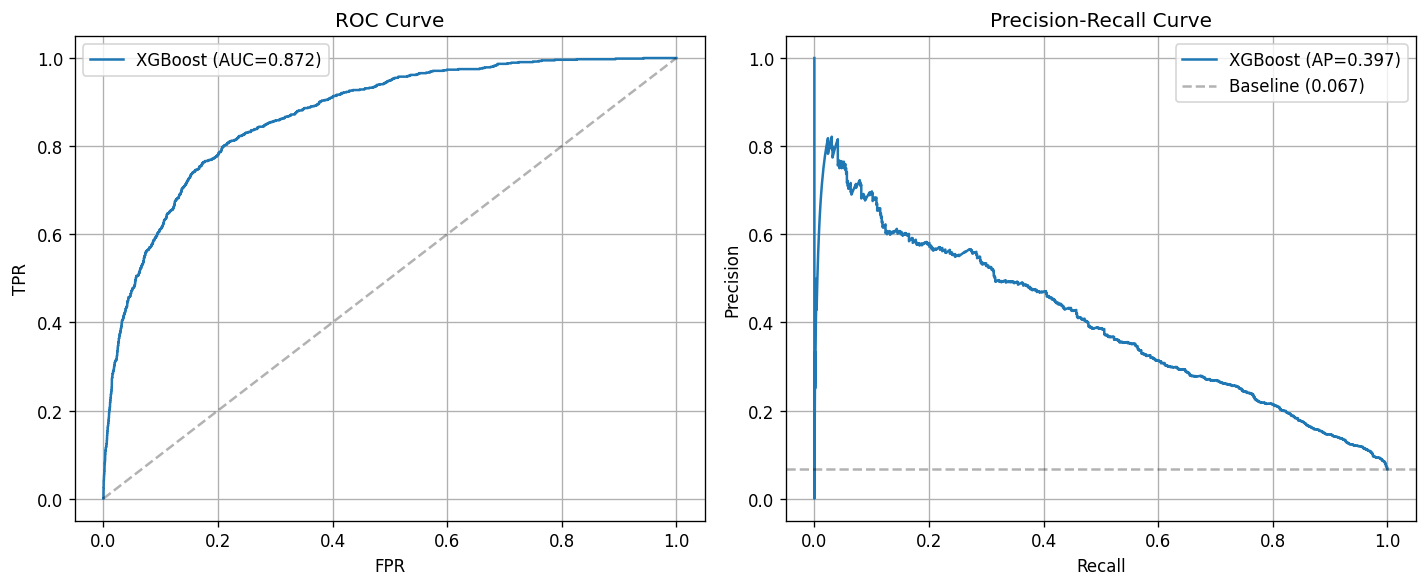

Interpretation:
- The ROC curve confirms strong ranking quality, but the PR curve is the better operational view for a low-base-rate problem.
- A PR curve that stays well above the baseline line means the model is surfacing more real overtakes than random selection would.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(y, probas_cv)
axes[0].plot(fpr, tpr, label=f"XGBoost (AUC={roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curve"); axes[0].legend()

prec, rec, _ = precision_recall_curve(y, probas_cv)
axes[1].plot(rec, prec, label=f"XGBoost (AP={pr_auc:.3f})")
axes[1].axhline(y.mean(), color="k", ls="--", alpha=0.3, label=f"Baseline ({y.mean():.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve"); axes[1].legend()

plt.tight_layout(); plt.show()
print("Interpretation:")
print("- The ROC curve confirms strong ranking quality, but the PR curve is the better operational view for a low-base-rate problem.")
print("- A PR curve that stays well above the baseline line means the model is surfacing more real overtakes than random selection would.")


## 9. Calibration & multi-threshold evaluation (§3.4)

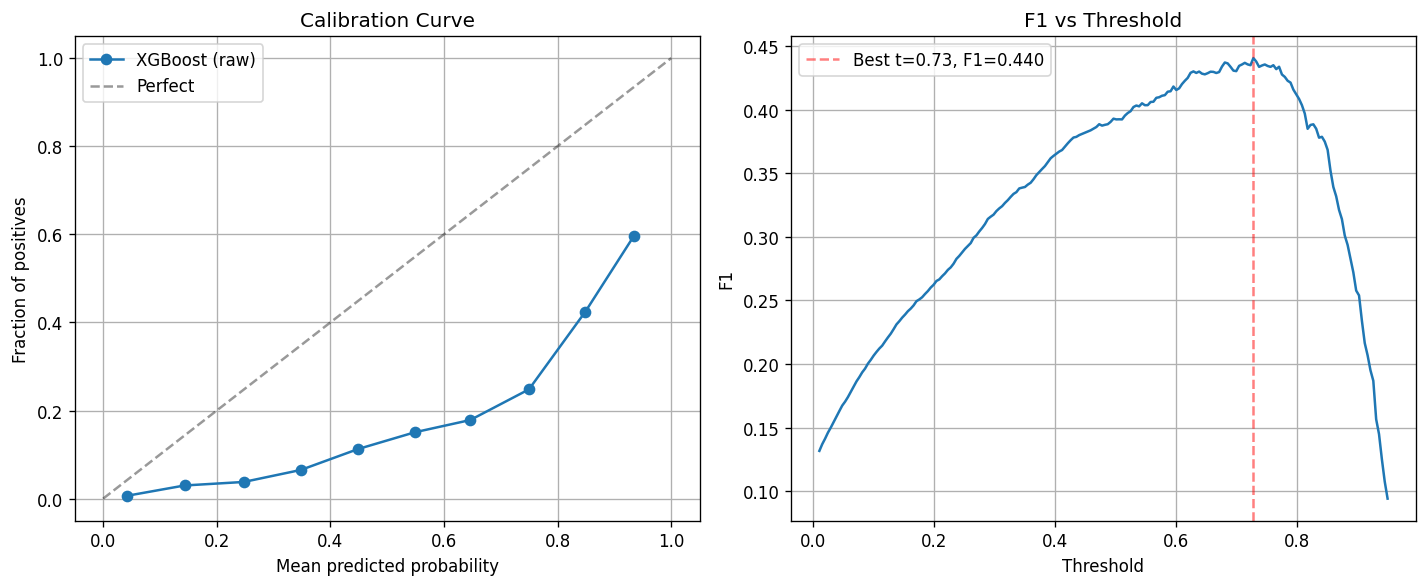

Best F1 threshold: 0.728 | Best F1: 0.440
Interpretation:
- The calibration curve shows whether predicted probabilities are too optimistic or too conservative before thresholding.
- The F1 sweep gives a practical operating point for the batch UI when the goal is to balance missed overtakes and false alarms.


In [10]:
# Calibration plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fp, mp = calibration_curve(y, probas_cv, n_bins=10, strategy="uniform")
axes[0].plot(mp, fp, marker="o", label="XGBoost (raw)")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfect")
axes[0].set_xlabel("Mean predicted probability")
axes[0].set_ylabel("Fraction of positives")
axes[0].set_title("Calibration Curve"); axes[0].legend()

thresholds = np.linspace(0.01, 0.95, 200)
f1s = [f1_score(y, (probas_cv >= t).astype(int), zero_division=0) for t in thresholds]
best_idx = np.argmax(f1s)
best_t, best_f1 = thresholds[best_idx], f1s[best_idx]
axes[1].plot(thresholds, f1s)
axes[1].axvline(best_t, color="r", ls="--", alpha=0.5, label=f"Best t={best_t:.2f}, F1={best_f1:.3f}")
axes[1].set_xlabel("Threshold"); axes[1].set_ylabel("F1")
axes[1].set_title("F1 vs Threshold"); axes[1].legend()

plt.tight_layout(); plt.show()
print(f"Best F1 threshold: {best_t:.3f} | Best F1: {best_f1:.3f}")
print("Interpretation:")
print("- The calibration curve shows whether predicted probabilities are too optimistic or too conservative before thresholding.")
print("- The F1 sweep gives a practical operating point for the batch UI when the goal is to balance missed overtakes and false alarms.")


## 10. Confusion matrix (best threshold)

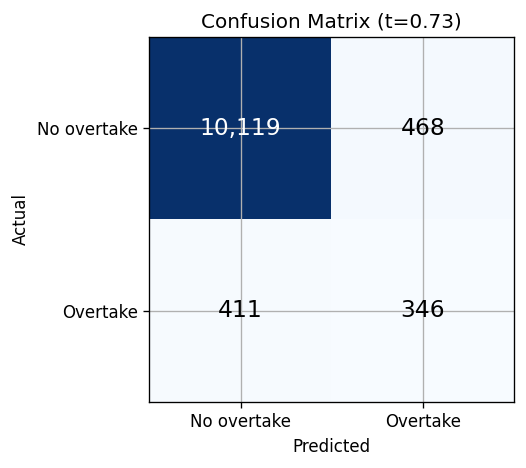

              precision    recall  f1-score   support

 No overtake       0.96      0.96      0.96     10587
    Overtake       0.43      0.46      0.44       757

    accuracy                           0.92     11344
   macro avg       0.69      0.71      0.70     11344
weighted avg       0.93      0.92      0.92     11344

Interpretation:
- This confusion matrix converts the ranking model into a concrete decision rule at the selected threshold.
- False negatives matter because they are missed overtakes, while false positives matter because they create noisy alerts in the app.


In [11]:
best_preds = (probas_cv >= best_t).astype(int)
cm = confusion_matrix(y, best_preds)

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["No overtake", "Overtake"])
ax.set_yticklabels(["No overtake", "Overtake"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix (t={best_t:.2f})")
plt.tight_layout(); plt.show()

print(classification_report(y, best_preds, target_names=["No overtake", "Overtake"]))
print("Interpretation:")
print("- This confusion matrix converts the ranking model into a concrete decision rule at the selected threshold.")
print("- False negatives matter because they are missed overtakes, while false positives matter because they create noisy alerts in the app.")


## 11. Feature importance

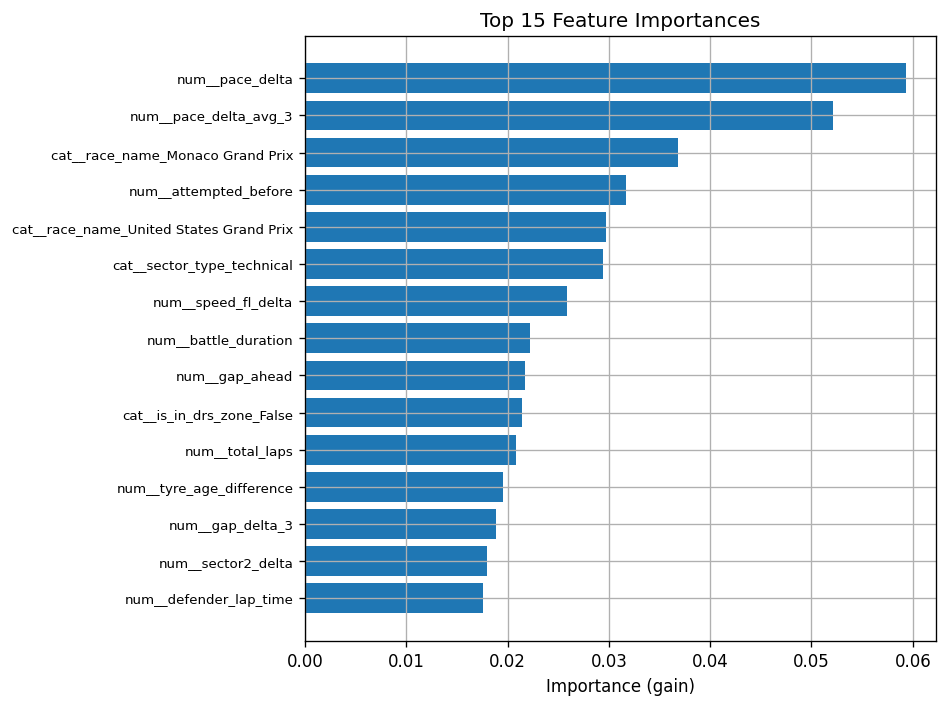

                                feature  importance
                        num__pace_delta    0.059324
                  num__pace_delta_avg_3    0.052098
       cat__race_name_Monaco Grand Prix    0.036873
                  num__attempted_before    0.031663
cat__race_name_United States Grand Prix    0.029726
             cat__sector_type_technical    0.029401
                    num__speed_fl_delta    0.025876
                   num__battle_duration    0.022226
                         num__gap_ahead    0.021684
              cat__is_in_drs_zone_False    0.021380
                        num__total_laps    0.020812
               num__tyre_age_difference    0.019585
                       num__gap_delta_3    0.018875
                     num__sector2_delta    0.017942
                 num__defender_lap_time    0.017600

Interpretation:
- The top-gain features show which signals the tree model relies on most when separating overtakes from non-overtakes.
- This ranking is useful for san

In [12]:
fi_clf = xgb.XGBClassifier(**best_params)
fi_clf.fit(X_transformed, y)

ohe_feature_names = preprocessor.get_feature_names_out()
importances = fi_clf.feature_importances_

fi_df = pd.DataFrame({"feature": ohe_feature_names, "importance": importances})
fi_df = fi_df.sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(len(fi_df)), fi_df["importance"].values)
ax.set_yticks(range(len(fi_df)))
ax.set_yticklabels(fi_df["feature"].values, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Importance (gain)")
ax.set_title("Top 15 Feature Importances")
plt.tight_layout(); plt.show()

print(fi_df.to_string(index=False))
print("\nInterpretation:")
print("- The top-gain features show which signals the tree model relies on most when separating overtakes from non-overtakes.")
print("- This ranking is useful for sanity-checking whether the model is learning race dynamics rather than arbitrary identifiers.")


## 15. Save model artefacts

In [13]:
import joblib
import json as _json
import datetime

ARTIFACTS_DIR = ROOT / "models" / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)

final_xgb = xgb.XGBClassifier(**best_params)
final_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])
X_all = final_preprocessor.fit_transform(X)
final_cal = CalibratedClassifierCV(final_xgb, method="isotonic", cv=5)
final_cal.fit(X_all, y)

full_pipeline = Pipeline([
    ("preprocess", final_preprocessor),
    ("classifier", final_cal),
])

model_path = ARTIFACTS_DIR / "overtake_model_v4.pkl"
meta_path  = ARTIFACTS_DIR / "overtake_model_v4_meta.json"

joblib.dump(full_pipeline, model_path)

meta = {
    "model": "XGBoost",
    "calibration": "isotonic",
    "features": FEATURE_COLS,
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "best_params": {k: v for k, v in best_params.items() if k != "n_jobs"},
    "threshold": float(best_t),
    "train_years": TRAIN_YEARS,
    "test_years": TEST_YEARS,
    "train_rows": int(len(X)),
    "test_rows": int(len(X_test)) if X_test is not None else 0,
    "overtake_rate": float(y.mean()),
    "cv_metrics": {
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "brier": float(brier),
    },
    "data_version": "v4",
    "baseline_model": "v3 IP02 (model_testing_3, data v3)",
    "saved_at": datetime.datetime.now().isoformat(),
}
meta_path.write_text(_json.dumps(meta, indent=2))

print(f"Model saved    -> {model_path}")
print(f"Metadata saved -> {meta_path}")
print(f"Trained on     : {TRAIN_YEARS}  ({len(X):,} battles)")
print(f"Decision threshold: {best_t:.3f}")


Model saved    -> /Users/aminnami/Desktop/hamid/ai_in_industry/formula1-overtake-prediction/models/artifacts/overtake_model_v4.pkl
Metadata saved -> /Users/aminnami/Desktop/hamid/ai_in_industry/formula1-overtake-prediction/models/artifacts/overtake_model_v4_meta.json
Trained on     : [2022, 2023, 2024]  (11,344 battles)
Decision threshold: 0.728


## 16. Holdout evaluation on 2025 data

The model is now applied to the **unseen 2025 season**. No 2025 data was used for training, feature engineering thresholds, or threshold selection.

2025 Holdout Results (per-lap)
  ROC-AUC  : 0.8950
  PR-AUC   : 0.4691
  Brier    : 0.0362

              precision    recall  f1-score   support

 No overtake       0.95      1.00      0.98      4398
    Overtake       0.78      0.12      0.20       243

    accuracy                           0.95      4641
   macro avg       0.87      0.56      0.59      4641
weighted avg       0.94      0.95      0.93      4641



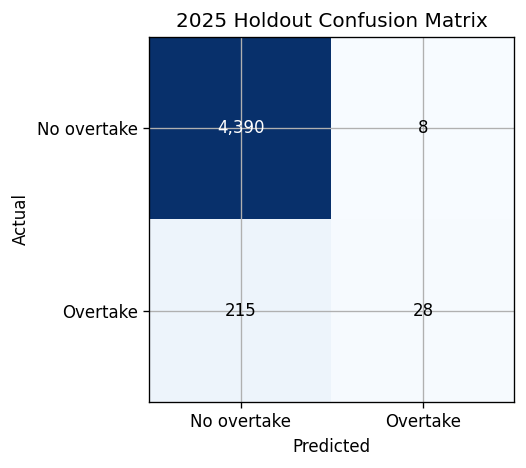

               race_name  rows  actual_positive_rate  predicted_positive_rate  mean_probability
  Mexico City Grand Prix   210              0.080952                 0.014286          0.049372
United States Grand Prix   181              0.077348                 0.005525          0.075122
      Spanish Grand Prix   198              0.075758                 0.010101          0.062816
      Bahrain Grand Prix   299              0.073579                 0.013378          0.066105
     Canadian Grand Prix   305              0.072131                 0.003279          0.051772
     Austrian Grand Prix   226              0.070796                 0.004425          0.034572
      Italian Grand Prix   568              0.063380                 0.007042          0.042720
    Abu Dhabi Grand Prix   272              0.062500                 0.000000          0.062774
   Australian Grand Prix   113              0.061947                 0.000000          0.038530
Saudi Arabian Grand Prix   183          

In [14]:
if X_test is not None and y_test is not None:
    probas_2025 = full_pipeline.predict_proba(X_test)[:, 1]
    preds_2025  = (probas_2025 >= best_t).astype(int)

    roc_25 = roc_auc_score(y_test, probas_2025)
    pr_25  = average_precision_score(y_test, probas_2025)
    brier_25 = brier_score_loss(y_test, probas_2025)
    cm_25 = confusion_matrix(y_test, preds_2025)

    print("2025 Holdout Results (per-lap)")
    print("=" * 40)
    print(f"  ROC-AUC  : {roc_25:.4f}")
    print(f"  PR-AUC   : {pr_25:.4f}")
    print(f"  Brier    : {brier_25:.4f}")
    print()
    print(classification_report(y_test, preds_2025, target_names=["No overtake", "Overtake"]))

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(cm_25, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm_25[i, j]:,}", ha="center", va="center",
                    color="white" if cm_25[i, j] > cm_25.max() / 2 else "black")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["No overtake", "Overtake"])
    ax.set_yticklabels(["No overtake", "Overtake"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title("2025 Holdout Confusion Matrix")
    plt.tight_layout(); plt.show()

    meta = _json.loads(meta_path.read_text())
    meta["holdout_metrics"] = {
        "roc_auc": float(roc_25),
        "pr_auc": float(pr_25),
        "brier": float(brier_25),
        "best_f1_threshold": float(best_t),
        "confusion_matrix": cm_25.tolist(),
    }
    meta_path.write_text(_json.dumps(meta, indent=2))

    race_summary = (
        pd.DataFrame({"race_name": df_test["race_name"].values, "actual": y_test, "proba": probas_2025, "pred": preds_2025})
        .groupby("race_name", as_index=False)
        .agg(rows=("actual", "size"), actual_positive_rate=("actual", "mean"), predicted_positive_rate=("pred", "mean"), mean_probability=("proba", "mean"))
        .sort_values("actual_positive_rate", ascending=False)
    )
    print(race_summary.head(10).to_string(index=False))
    print("\nInterpretation:")
    print("- The 2025 holdout shows how well the model generalizes to a season it never saw during training.")
    print("- Comparing actual and predicted positive rates by race helps spot circuits where the model is over-calling or under-calling overtakes.")
else:
    print("Skipping holdout — 2025 data not available.")
